In [51]:
# 모듈 import
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

In [3]:
train_dir = './data/cat_dog_small/train'
validation_dir = './data/cat_dog_small/validation'
test_dir = './data/cat_dog_small/test'

In [52]:
# ImageDataGenerator 생성
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                                  rotation_range=25,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  fill_mode='nearest')
validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [53]:
# ImageDataGenerator 설정
train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=['cats','dogs'],
    target_size=(380,380),
    batch_size=20,
    class_mode='binary'
)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    classes=['cats','dogs'],
    target_size=(380,380),
    batch_size=20,
    class_mode='binary'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    classes=['cats','dogs'],
    target_size=(380,380),
    batch_size=20,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [54]:
# model 구현

model_base = EfficientNetB4(weights='imagenet',
                           include_top=False,
                           input_shape=(380,380,3))

model_base.trainable = False

model = Sequential()

model.add(model_base)
model.add(Flatten())
model.add(Dense(units=100))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(rate=0.2))

model.add(Dense(units=1,
               activation='sigmoid'))

In [55]:
es_callback = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True,
                           verbose=1)
cp_callback = ModelCheckpoint(filepath='./efficientnetb4.weights.h5',
                             save_best_only=True,
                             save_weights_only=True,
                             monitor='val_accuracy',
                             verbose=1)

In [56]:
# model 설정
model.compile(optimizer=Adam(learning_rate=1e-4),
             loss='binary_crossentropy',
             metrics=['acc'])

In [57]:
# model 학습
model.fit(train_generator,
         steps_per_epoch=100,
         epochs=100,
         validation_data=validation_generator,
         validation_steps=50,
         callbacks=[es_callback, cp_callback],
         verbose=1)

Epoch 1/100
100/100 [==============================] - 45s 379ms/step - loss: 0.0721 - acc: 0.9750 - val_loss: 0.0148 - val_acc: 0.9960
Epoch 2/100
100/100 [==============================] - 38s 383ms/step - loss: 0.0295 - acc: 0.9930 - val_loss: 0.0143 - val_acc: 0.9960
Epoch 3/100
100/100 [==============================] - 40s 396ms/step - loss: 0.0381 - acc: 0.9870 - val_loss: 0.0122 - val_acc: 0.9960
Epoch 4/100
100/100 [==============================] - 40s 395ms/step - loss: 0.0256 - acc: 0.9935 - val_loss: 0.0133 - val_acc: 0.9960
Epoch 5/100
100/100 [==============================] - 40s 403ms/step - loss: 0.0270 - acc: 0.9920 - val_loss: 0.0165 - val_acc: 0.9960
Epoch 6/100
100/100 [==============================] - 41s 410ms/step - loss: 0.0190 - acc: 0.9990 - val_loss: 0.0136 - val_acc: 0.9960
Epoch 7/100
100/100 [==============================] - 41s 404ms/step - loss: 0.0190 - acc: 0.9975 - val_loss: 0.0141 - val_acc: 0.9960
Epoch 8/100
Restoring model weights from the end

In [58]:
# Fine Tuning
model_base.trainable = True

for layer in model_base.layers[:-30]:
    layer.trainable = False

In [59]:
# Learning Rate 알아내는 사용자 정의 Callback
initial_lr = 1e-8

class LRFinderCallback(tf.keras.callbacks.Callback):
    def __init__(self, min_lr=1e-8, max_lr=10, steps=100):
        super(LRFinderCallback, self).__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.total_steps = steps
        self.history = {'lr': [], 'loss': []}

    def on_batch_end(self, batch, logs=None):
        lr = self.min_lr * (self.max_lr / self.min_lr) ** (batch / self.total_steps)
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        self.history['lr'].append(lr)
        self.history['loss'].append(logs['loss'])

# 콜백 인스턴스 생성
lr_finder = LRFinderCallback(min_lr=1e-8, max_lr=1, steps=100)

In [60]:
# model 재설정
model.compile(optimizer=Adam(learning_rate=1e-5),
             loss='binary_crossentropy',
             metrics=['acc'])

In [61]:
# model 재학습
model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=1,
    validation_data=validation_generator,
    validation_steps=50,
    callbacks=[lr_finder],
    verbose=1
)

100/100 [==============================] - 48s 400ms/step - loss: 0.0969 - acc: 0.9680 - val_loss: 115746.3828 - val_acc: 0.5990


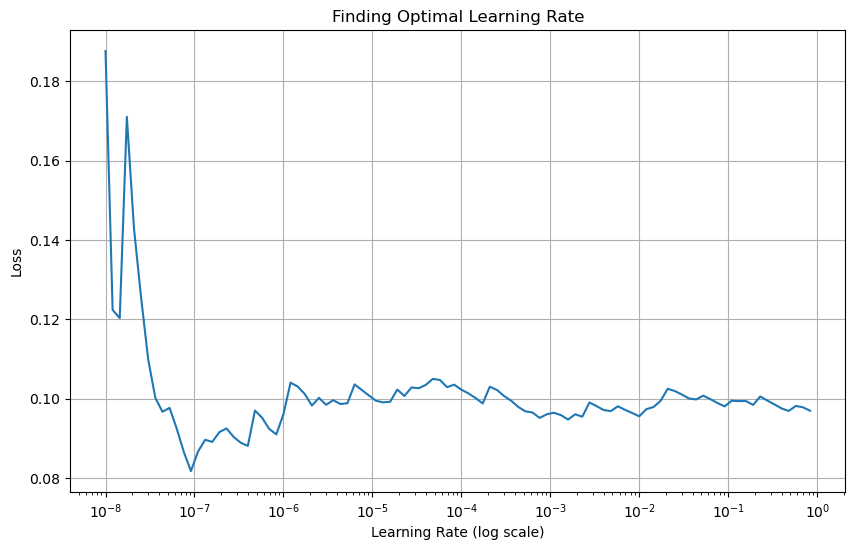

In [62]:
# loss vs learning rate 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(lr_finder.history['lr'], lr_finder.history['loss'])
plt.xscale('log')   # x축은 log scale로 보면 좋음
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Loss')
plt.title('Finding Optimal Learning Rate')
plt.grid(True)
plt.show()

In [63]:
# 최적 learning rate 로 적용하기
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['acc']
)

In [64]:
# model 재학습
model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=20,
    validation_data=validation_generator,
    validation_steps=50,
    callbacks=[es_callback, cp_callback],
    verbose=1
)

Epoch 1/20
100/100 [==============================] - 55s 457ms/step - loss: 0.3231 - acc: 0.9480 - val_loss: 0.5612 - val_acc: 0.9700
Epoch 2/20
100/100 [==============================] - 46s 454ms/step - loss: 0.3633 - acc: 0.9420 - val_loss: 0.2384 - val_acc: 0.9730
Epoch 3/20
100/100 [==============================] - 46s 464ms/step - loss: 0.3490 - acc: 0.9470 - val_loss: 0.1928 - val_acc: 0.9750
Epoch 4/20
100/100 [==============================] - 45s 452ms/step - loss: 0.3388 - acc: 0.9460 - val_loss: 0.1800 - val_acc: 0.9730
Epoch 5/20
100/100 [==============================] - 47s 469ms/step - loss: 0.3390 - acc: 0.9430 - val_loss: 0.1748 - val_acc: 0.9730
Epoch 6/20
100/100 [==============================] - 49s 486ms/step - loss: 0.2796 - acc: 0.9475 - val_loss: 0.1693 - val_acc: 0.9730
Epoch 7/20
100/100 [==============================] - 52s 519ms/step - loss: 0.3232 - acc: 0.9475 - val_loss: 0.1693 - val_acc: 0.9730
Epoch 8/20
100/100 [==============================] - 5

In [ ]:
# 평가
model.fit(train_generator,
          steps_per_epoch=100,
          epochs=15,
          validation_data=test_generator,
          validation_steps=50,
          verbose=1)

Epoch 1/15
100/100 [==============================] - 45s 449ms/step - loss: 0.2503 - acc: 0.9615 - val_loss: 0.1166 - val_acc: 0.9780
Epoch 2/15
100/100 [==============================] - 43s 427ms/step - loss: 0.2220 - acc: 0.9665 - val_loss: 0.1139 - val_acc: 0.9780
Epoch 3/15
100/100 [==============================] - 42s 420ms/step - loss: 0.2533 - acc: 0.9600 - val_loss: 0.1117 - val_acc: 0.9780
Epoch 4/15
100/100 [==============================] - 43s 433ms/step - loss: 0.2189 - acc: 0.9590 - val_loss: 0.1103 - val_acc: 0.9780
Epoch 5/15
100/100 [==============================] - 43s 428ms/step - loss: 0.1994 - acc: 0.9605 - val_loss: 0.1096 - val_acc: 0.9800
Epoch 6/15
100/100 [==============================] - 46s 457ms/step - loss: 0.1990 - acc: 0.9685 - val_loss: 0.1072 - val_acc: 0.9800
Epoch 7/15
 65/100 [==================>...........] - ETA: 12s - loss: 0.1999 - acc: 0.9623

In [ ]:
predict = model.evaluate(test_generator)

print(predict)